In [6]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib as plt 
from sklearn.preprocessing import StandardScaler

In [3]:
#loading dataset
df = pd.read_csv("seeds_data.csv") 
df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [5]:
#EDA
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Feature_1  210 non-null    float64
 1   Feature_2  210 non-null    float64
 2   Feature_3  210 non-null    float64
 3   Feature_4  210 non-null    float64
 4   Feature_5  210 non-null    float64
 5   Feature_6  210 non-null    float64
 6   Feature_7  210 non-null    float64
 7   Class      210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB


Feature_1    0
Feature_2    0
Feature_3    0
Feature_4    0
Feature_5    0
Feature_6    0
Feature_7    0
Class        0
dtype: int64

In [7]:
#separating features and target
X = df.drop(columns=["Class"])
y = df["Class"]

In [8]:
#re-checking feature types
X.dtypes

Feature_1    float64
Feature_2    float64
Feature_3    float64
Feature_4    float64
Feature_5    float64
Feature_6    float64
Feature_7    float64
dtype: object

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [18]:
def find_closest_centroids(X_scaled, centroids):
    m = X_scaled.shape[0]
    K = centroids.shape[0]
    idx = np.zeros(m, dtype=int)

    for i in range(m):
        min_dist = np.inf
        best_centroid = 0

        for j in range(K):
            dist = np.sum((X_scaled[i] - centroids[j]) ** 2)
            if dist < min_dist:
                min_dist = dist
                best_centroid = j

        idx[i] = best_centroid

    return idx


In [23]:
# Computing centroids
def compute_centroids(X_scaled, idx, K):
    m, n = X_scaled.shape
    new_centroids = np.zeros((K, n))

    for i in range(K):
        sum_of_points = np.zeros(n)
        count = 0

        for j in range(m):
            if idx[j] == i:
                sum_of_points += X_scaled[j]
                count += 1

        # Handle empty cluster
        if count != 0:
            new_centroids[i] = sum_of_points / count
        else:
            # Reinitialize centroid randomly if cluster is empty
            new_centroids[i] = X_scaled[np.random.randint(0, m)]

    return new_centroids


In [24]:
K = 3
max_iters = 100
tol = 1e-4    #tolerance threshold

np.random.seed(42)
random_idx = np.random.choice(X_scaled.shape[0], K, replace=False)
centroids = X_scaled[random_idx]

for it in range(max_iters):

    #  assign clusters
    idx = find_closest_centroids(X_scaled, centroids)

    #  update centroids
    new_centroids = compute_centroids(X_scaled, idx, K)

    # Step 3: check convergence
    if np.allclose(centroids, new_centroids, atol=tol):
        print(f"Converged at iteration {it}")
        break

    centroids = new_centroids


Converged at iteration 4


In [25]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


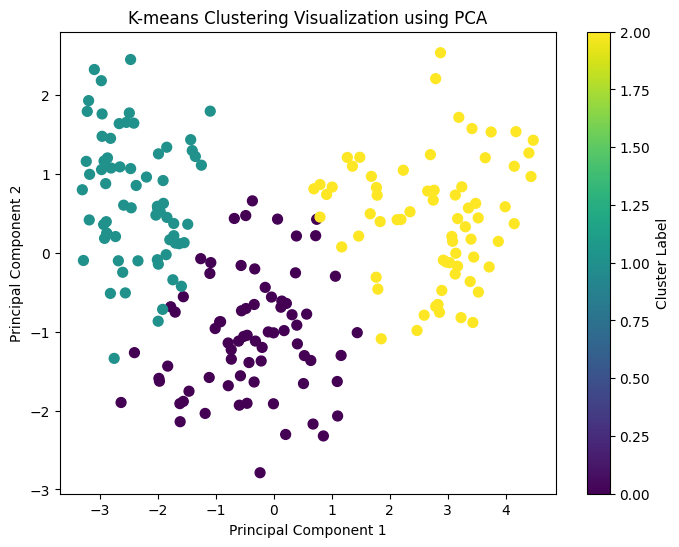

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=idx,
    cmap='viridis',
    s=50
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-means Clustering Visualization using PCA")
plt.colorbar(label="Cluster Label")
plt.show()


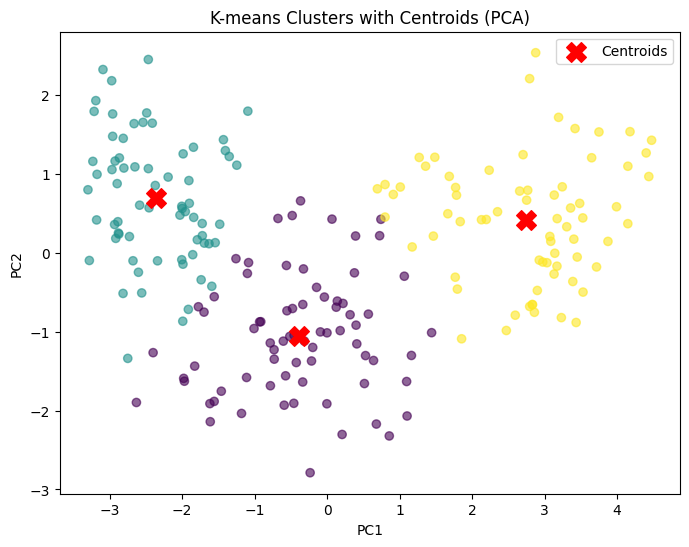

In [27]:
centroids_pca = pca.transform(centroids)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=idx, cmap='viridis', alpha=0.6)
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    c='red',
    s=200,
    marker='X',
    label='Centroids'
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-means Clusters with Centroids (PCA)")
plt.legend()
plt.show()


In [28]:
centroids_original = scaler.inverse_transform(centroids)
print("Final cluster centers (original feature scale):")
print(centroids_original)


Final cluster centers (original feature scale):
[[14.28643836 14.26493151  0.88091233  5.48690411  3.24356164  2.66723562
   5.08754795]
 [11.83720588 13.24161765  0.84761324  5.23342647  2.84254412  4.88033824
   5.11523529]
 [18.40782609 16.16927536  0.88355652  6.16775362  3.68455072  3.63001449
   6.03576812]]


In [29]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, idx)
print("Silhouette Score:", score)


Silhouette Score: 0.4038543508752402
